# 📊 03. Interactive Dashboard

MicroFactual includes an interactive dashboard powered by `ExplainerDashboard` to deeply inspect your models.

**Features:**
- Inspect individual predictions
- Feature importance / Shapley values
- Confusion Matrix & ROC analysis
- "What-if" scenarios

In [1]:
import microfactual as mf
from microfactual import MicrobiomeClassifier, MicrobiomeDataset

## 1. Train a Model

First, we need a trained model to inspect.

In [2]:
# Load data
dataset = MicrobiomeDataset.from_files(
    abundance_file="../datasets/abundance_crc.txt",
    metadata_file="../datasets/metadata_crc.txt",
    target_column="Group",
    sample_column="Sample ID",
)

# specific column names for better dashboard display
# (MicroFactual handles sanitation automatically, but good labels help)

# Train simple model
clf = MicrobiomeClassifier(algorithm="random_forest", n_estimators=50)
clf.fit(dataset.X, dataset.y)

,algorithm,'random_forest'
,preprocessing,'auto'


## 2. Static Visualizations

Before the dashboard, let's look at the static plots available.

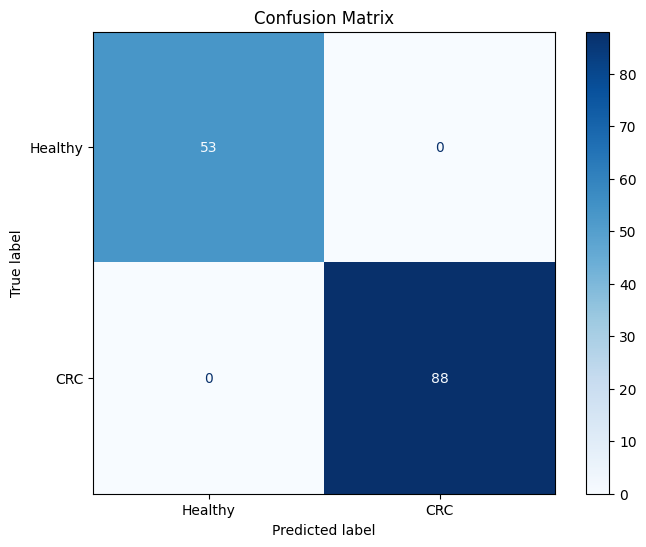

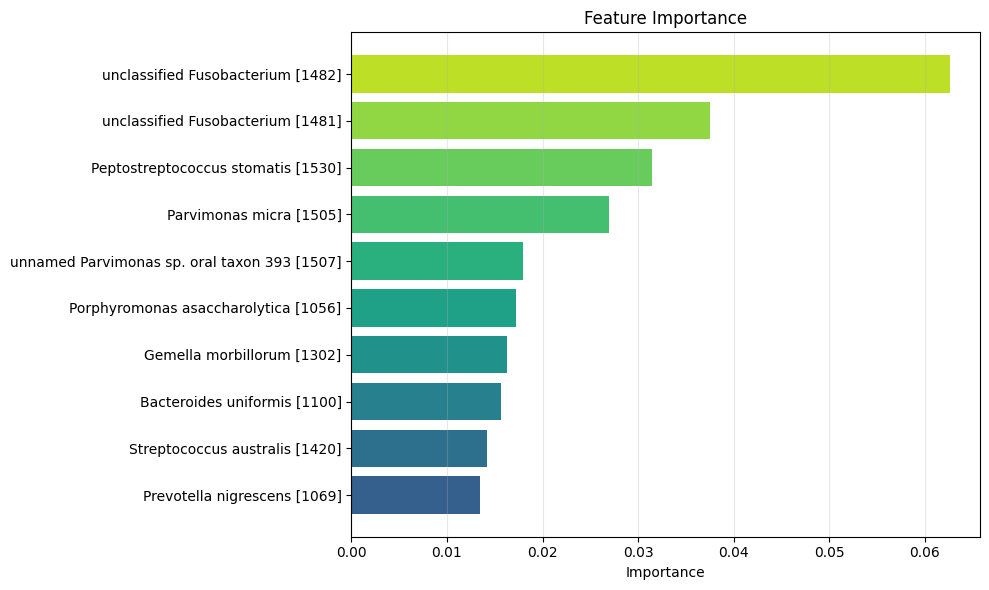

In [3]:
import matplotlib.pyplot as plt

# 1. Confusion Matrix
y_pred = clf.predict(dataset.X)
fig = mf.plot_confusion_matrix(dataset.y, y_pred, labels=["Healthy", "CRC"])
plt.show()

# 2. Feature Importance (Top 10)
# Extract transformed feature names
feature_names = clf.pipeline_[:-1].get_feature_names_out(dataset.feature_names)

fig = mf.plot_feature_importance(clf, feature_names=feature_names, top_n=10)
plt.show()

## 3. Launch Interactive Dashboard

Run the cell below to start the dashboard server. It will open in your browser or be displayed inline.

In [4]:
# Launch dashboard (runs on localhost:8050 by default)
# Use run=False if you just want to create the object
db = mf.launch_dashboard(model=clf, X=dataset.X, y=dataset.y, run=True, port=8050)

Note: shap values for shap='kernel' normally get calculated against X_background, but paramater X_background=None, so setting X_background=shap.sample(X, 50)...
Generating self.shap_explainer = shap.KernelExplainer(model, X, link='identity')
Provided model function fails when applied to the provided data set.


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- unnamed Actinomyces sp_ oral taxon 170 [881]
- unnamed Actinomyces sp_ oral taxon 180 [879]
- unnamed Actinomyces sp_ oral taxon 448 [883]
- unnamed Actinomyces sp_ oral taxon 848 [897]
- unnamed Alistipes sp_ HGB5 [1053]
- ...
Feature names seen at fit time, yet now missing:
- unnamed Actinomyces sp. oral taxon 170 [881]
- unnamed Actinomyces sp. oral taxon 180 [879]
- unnamed Actinomyces sp. oral taxon 448 [883]
- unnamed Actinomyces sp. oral taxon 848 [897]
- unnamed Alistipes sp. HGB5 [1053]
- ...


> **Note:** To stop the dashboard, interrupt the kernel (Stop button).